###Introduction

PySpark is the Python API for Apache Spark, an open-source big data processing framework. It provides a powerful and scalable platform for data processing and analytics. This notebook will cover the basics of PySpark and guide you through some fundamental concepts and operations.

###1. Installing PySpark


In [10]:
! pip install pySpark

###2. Importing Required Library

In [30]:
import pyspark
from pyspark.sql import SparkSession
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


###3. Initializing SparkSession

To interact with Spark, we need to create a SparkSession, which serves as the entry point for using PySpark.

In [2]:
spark=SparkSession.builder.appName("Pyspark Basics").getOrCreate()

###4. Loading Data

PySpark supports various data formats, including CSV, JSON, Parquet, and more. Let's see how to load a CSV file into a PySpark DataFrame.

In [8]:
from google.colab import files
uploaded = files.upload()


Saving Stores.csv to Stores (3).csv


In [9]:

# Read a CSV File
data = spark.read.csv("/content/Stores.csv", header=True, inferSchema=True)


###5. Exploring Data

In [11]:
# Display the first few rows of the DataFrame
data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        1|      1659|           1961|                 530|      66490|
|        2|      1461|           1752|                 210|      39820|
|        3|      1340|           1609|                 720|      54010|
|        4|      1451|           1748|                 620|      53730|
|        5|      1770|           2111|                 450|      46620|
|        6|      1442|           1733|                 760|      45260|
|        7|      1542|           1858|                1030|      72240|
|        8|      1261|           1507|                1020|      37720|
|        9|      1090|           1321|                 680|      46310|
|       10|      1030|           1235|                1130|      44150|
|       11|      1187|           1439|                1090|     

### Displaying Schema

In [12]:
# Display The schema of the DataFrame
data.printSchema()

root
 |-- Store ID : integer (nullable = true)
 |-- Store_Area: integer (nullable = true)
 |-- Items_Available: integer (nullable = true)
 |-- Daily_Customer_Count: integer (nullable = true)
 |-- Store_Sales: integer (nullable = true)



### Row Count

In [13]:
# Count Number of Rows in DataFrame
data.count()

896

### Performing Statistivcal Analysis

In [14]:
# Get Summary of Statistics of Numerical Columns
data.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|
+-------+----------------+------------------+------------------+--------------------+------------------+
|  count|             896|               896|               896|                 896|               896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|
|    min|               1|               775|               932|                  10|             14920|
|    max|             896|              2229|              2667|                1560|            116320|
+-------+----------------+------------------+------------------+--------------------+------------------+



###6. Data Transformation

In [19]:
# Select Specific columns
selected_data= data.select("`Store ID `","Store_Sales")
# Show that Selected Data
selected_data.show()

+---------+-----------+
|Store ID |Store_Sales|
+---------+-----------+
|        1|      66490|
|        2|      39820|
|        3|      54010|
|        4|      53730|
|        5|      46620|
|        6|      45260|
|        7|      72240|
|        8|      37720|
|        9|      46310|
|       10|      44150|
|       11|      71280|
|       12|      57620|
|       13|      60470|
|       14|      59130|
|       15|      66360|
|       16|      78870|
|       17|      77250|
|       18|      38170|
|       19|      63540|
|       20|      40190|
+---------+-----------+
only showing top 20 rows


###Filtering Row based on a condition

In [20]:
filtered_data= data.filter(data['Daily_Customer_Count']<500)
filtered_data.show()

+---------+----------+---------------+--------------------+-----------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|
+---------+----------+---------------+--------------------+-----------+
|        2|      1461|           1752|                 210|      39820|
|        5|      1770|           2111|                 450|      46620|
|       21|      1421|           1700|                 370|      43460|
|       40|      1270|           1516|                  10|      45480|
|       53|      1074|           1288|                 320|      70450|
|       60|      1756|           2070|                 460|      53870|
|       61|      1704|           2045|                 300|      71300|
|       68|      1416|           1681|                 290|      72710|
|       77|      1267|           1520|                 450|      26770|
|       83|      1441|           1723|                 330|      57860|
|       86|      1468|           1760|                 280|     

### ADD New Column

In [22]:
data_with_new_column = data.withColumn("Avg_sales_per_person",data["Store_Sales"] / data["Daily_Customer_Count"])
data_with_new_column.show()

+---------+----------+---------------+--------------------+-----------+--------------------+
|Store ID |Store_Area|Items_Available|Daily_Customer_Count|Store_Sales|Avg_sales_per_person|
+---------+----------+---------------+--------------------+-----------+--------------------+
|        1|      1659|           1961|                 530|      66490|  125.45283018867924|
|        2|      1461|           1752|                 210|      39820|  189.61904761904762|
|        3|      1340|           1609|                 720|      54010|   75.01388888888889|
|        4|      1451|           1748|                 620|      53730|   86.66129032258064|
|        5|      1770|           2111|                 450|      46620|               103.6|
|        6|      1442|           1733|                 760|      45260|   59.55263157894737|
|        7|      1542|           1858|                1030|      72240|   70.13592233009709|
|        8|      1261|           1507|                1020|      37720

In [23]:

data_with_new_column.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|Avg_sales_per_person|
+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|  count|             896|               896|               896|                 896|               896|                 896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|   94.04317457240369|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|  162.81909882435673|
|    min|               1|               775|               932|                  10|             14920|  15.070707070707071|
|    max|             896|              2229|              2667|                1560|            116320|              

### Group by Column and Compute Aggregation Function

In [24]:
grouped_data= data.groupBy("`Store ID `").agg({"Store_Sales":"sum"})
grouped_data.show()

+---------+----------------+
|Store ID |sum(Store_Sales)|
+---------+----------------+
|      148|           50360|
|      463|           43190|
|      471|           71240|
|      496|           49750|
|      833|           38510|
|      243|           69940|
|      392|           60980|
|      540|           39030|
|      623|           50730|
|      737|           59530|
|      858|           79410|
|       31|           80140|
|      516|           56440|
|       85|           90180|
|      137|           60940|
|      251|           43390|
|      451|           75880|
|      580|           79780|
|      808|           49030|
|       65|           58660|
+---------+----------------+
only showing top 20 rows


##7. Data Agrregation

In [26]:
# Compute the average of a column
average_value=data.selectExpr("avg((Store_Sales))").collect()[0][0]
average_value

59351.30580357143

##8. Data Visualization

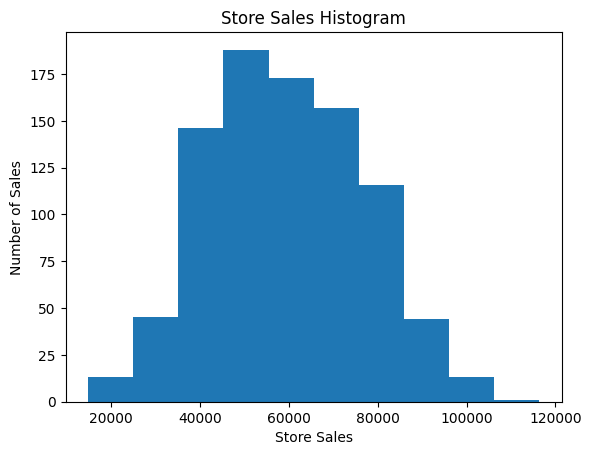

In [32]:
# Conver PySpark DataFrame into Pandas DataFrame
pandas_data= data.toPandas()

# Create a Histogram
plt.hist(pandas_data["Store_Sales"],bins=10)
plt.xlabel("Store Sales")
plt.ylabel("Number of Sales")
plt.title("Store Sales Histogram")
plt.show()

###9. writing Data

In [35]:
data.write.parquet("output.parquet")
print("Done")

Done
